d= 2  vol ≈ 0.05670 ± 0.00012
d= 3  vol ≈ 0.09351 ± 0.00015
d= 4  vol ≈ 0.12924 ± 0.00017
d= 5  vol ≈ 0.15684 ± 0.00018
d=10  vol ≈ 0.23163 ± 0.00021
d=20  vol ≈ 0.26492 ± 0.00022


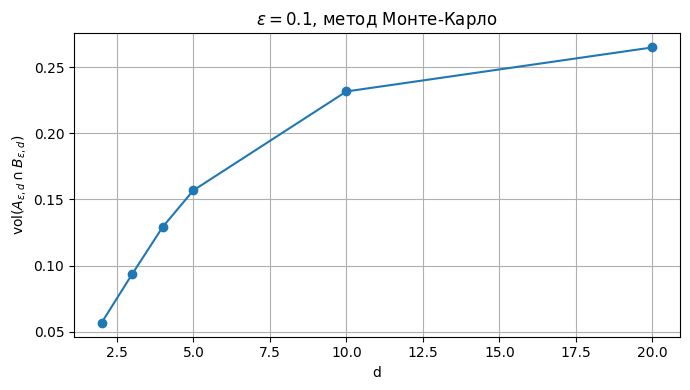

In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def mc_volume(eps, d, N=2_000_000, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.random((N, d))            # точки в [0,1]^d
    # расстояние до границы
    dB = np.minimum(X, 1 - X).min(axis=1)
    # расстояние до центральной плоскости (нормированное)
    dC = np.abs(X.sum(axis=1) - d/2) / np.sqrt(d)
    inside = (dB <= eps) & (dC <= eps)
    vol_est = inside.mean()
    # стандартная ошибка
    se = np.sqrt(vol_est * (1 - vol_est) / N)
    return vol_est, se

ds = [2, 3, 4, 5, 10, 20]
eps = 0.1
vols, ses = [], []
for d in ds:
    v, s = mc_volume(eps, d, N=4_000_000, seed=42)
    vols.append(v); ses.append(s)
    print(f"d={d:2d}  vol ≈ {v:.5f} ± {s:.5f}")

plt.figure(figsize=(7,4))
plt.errorbar(ds, vols, yerr=ses, fmt='o-', capsize=3)
plt.xlabel("d"); plt.ylabel(r"vol$(A_{\varepsilon,d}\cap B_{\varepsilon,d})$")
plt.title(r"$\varepsilon = 0.1$, метод Монте-Карло")
plt.grid(True); plt.tight_layout()
plt.savefig("mc_volume.png", dpi=100)
plt.show()